<a href="https://colab.research.google.com/github/AysunAllahverdiyeva/Data_analitika_2ci-hefte/blob/main/Layihe_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print("Setir ve sutun sayi:", df.shape)
print("\nSutunlarin veri tipleri:")
print(df.dtypes)
print("\nItkin (bos) deyerlerin sayi:")
print(df.isnull().sum())

df.head()

Setir ve sutun sayi: (541909, 8)

Sutunlarin veri tipleri:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Itkin (bos) deyerlerin sayi:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

legv_edilmis = df[df['InvoiceNo'].str.startswith('C')]

print("Legv edilmis sifaris setirlerinin sayi:", len(legv_edilmis))
print("Legv edilmis sifarislerin faizi:", round(len(legv_edilmis) / len(df) * 100, 2), "%")

legv_edilmis.head()

Legv edilmis sifaris setirlerinin sayi: 9288
Legv edilmis sifarislerin faizi: 1.71 %


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [ ]:
df_musteri = df.dropna(subset=['CustomerID'])

print("Evvelki setir sayi:", len(df))
print("CustomerID temizlendikden sonraki setir sayi:", len(df_musteri))
print("Cixarilan setir sayi:", len(df) - len(df_musteri))

df_musteri['CustomerID'] = df_musteri['CustomerID'].astype(int)

df_musteri.head()

Evvelki setir sayi: 541909
CustomerID temizlendikden sonraki setir sayi: 406829
Cixarilan setir sayi: 135080


/tmp/ipykernel_1489/3203846938.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_musteri['CustomerID'] = df_musteri['CustomerID'].astype(int)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [ ]:
qaytarimlar = df_musteri[df_musteri['Quantity'] < 0]

print("Menfi Miqdarli (qaytarim) setirlerin sayi:", len(qaytarimlar))
print("Umumi setirlerin ne qeder faizi qaytarimdir:", round(len(qaytarimlar) / len(df_musteri) * 100, 2), "%")

qaytarimlar.head()

Menfi Miqdarli (qaytarim) setirlerin sayi: 8905
Umumi setirlerin ne qeder faizi qaytarimdir: 2.19 %


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom


In [ ]:
df_musteri['Gelir'] = df_musteri['Quantity'] * df_musteri['UnitPrice']

print("Gelir sutunu yaradildi.")
print("\nUmumi Gelir (butun setirler uzre, qaytarimlar daxil):", round(df_musteri['Gelir'].sum(), 2), "GBP")

df_musteri[['InvoiceNo', 'Quantity', 'UnitPrice', 'Gelir']].head()

Gelir sutunu yaradildi.

Umumi Gelir (butun setirler uzre, qaytarimlar daxil): 8300065.81 GBP


/tmp/ipykernel_1489/745931757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_musteri['Gelir'] = df_musteri['Quantity'] * df_musteri['UnitPrice']


,InvoiceNo,Quantity,UnitPrice,Gelir
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [ ]:
musteri_xulasesi = df_musteri.groupby('CustomerID').agg(
    umumi_gelir=('Gelir', 'sum'),
    umumi_sifarisler=('InvoiceNo', 'nunique')
).reset_index()

musteri_xulasesi['orta_sifaris_deyeri'] = musteri_xulasesi['umumi_gelir'] / musteri_xulasesi['umumi_sifarisler']

musteri_xulasesi = musteri_xulasesi.sort_values('umumi_gelir', ascending=False)

print("Musteri sayi:", len(musteri_xulasesi))
musteri_xulasesi.head(10)

Musteri sayi: 4372


,CustomerID,umumi_gelir,umumi_sifarisler,orta_sifaris_deyeri
1703,14646,279489.02,77,3629.727532
4233,18102,256438.49,62,4136.104677
3758,17450,187482.17,55,3408.766727
1895,14911,132572.62,248,534.567016
55,12415,123725.45,26,4758.671154
1345,14156,113384.14,66,1717.941515
3801,17511,88125.38,46,1915.769130
3202,16684,65892.08,31,2125.550968
1005,13694,62653.10,60,1044.218333
2192,15311,59419.34,118,503.553729


In [ ]:
olke_xulasesi = df_musteri.groupby('Country').agg(
    umumi_gelir=('Gelir', 'sum'),
    umumi_sifarisler=('InvoiceNo', 'nunique')
).reset_index()

umumi_gelir_hamisi = olke_xulasesi['umumi_gelir'].sum()
olke_xulasesi['pay_faizi'] = round(olke_xulasesi['umumi_gelir'] / umumi_gelir_hamisi * 100, 2)

olke_xulasesi = olke_xulasesi.sort_values('umumi_gelir', ascending=False)

print("Olke sayi:", len(olke_xulasesi))
olke_xulasesi.head(10)

Olke sayi: 37


,Country,umumi_gelir,umumi_sifarisler,pay_faizi
35,United Kingdom,6767873.394,19857,81.54
23,Netherlands,284661.540,101,3.43
10,EIRE,250285.220,319,3.02
14,Germany,221698.210,603,2.67
13,France,196712.840,458,2.37
0,Australia,137077.270,69,1.65
32,Switzerland,55739.400,71,0.67
30,Spain,54774.580,105,0.66
3,Belgium,40910.960,119,0.49
31,Sweden,36595.910,46,0.44


Aylıq Gelir:
il_ay
2010-12     554604.020
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342506.380
Freq: M, Name: Gelir, dtype: float64

En yuksek gelirli ay: 2011-11 - 1132407.74 GBP


/tmp/ipykernel_1489/3266839452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_musteri['InvoiceDate'] = pd.to_datetime(df_musteri['InvoiceDate'])
/tmp/ipykernel_1489/3266839452.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_musteri['il_ay'] = df_musteri['InvoiceDate'].dt.to_period('M')


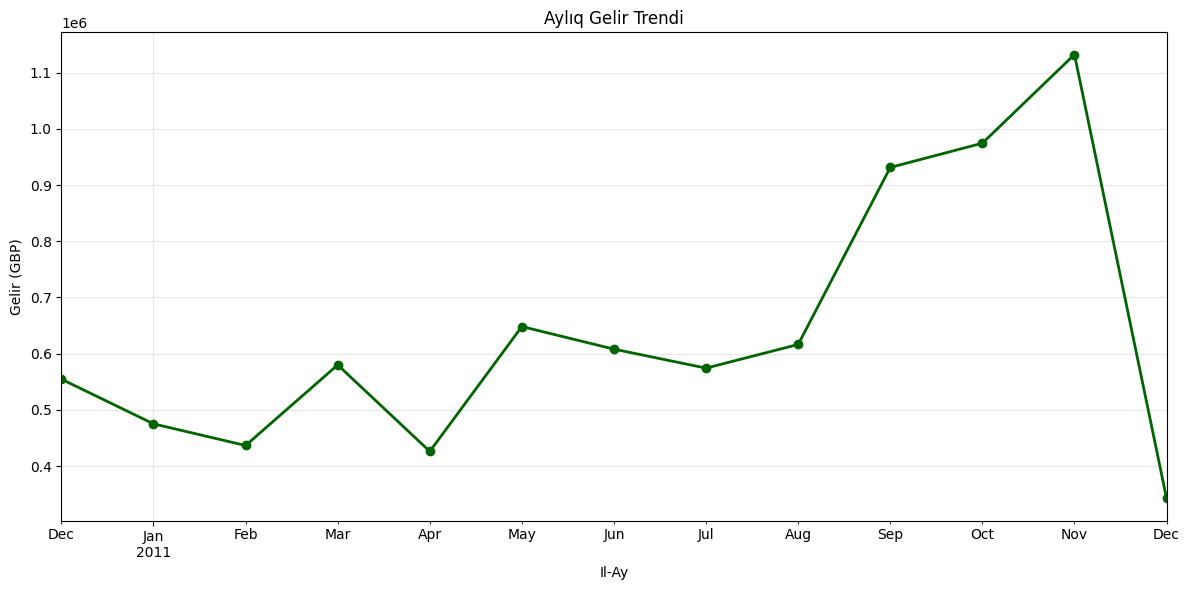

In [ ]:
df_musteri['InvoiceDate'] = pd.to_datetime(df_musteri['InvoiceDate'])

df_musteri['il_ay'] = df_musteri['InvoiceDate'].dt.to_period('M')

aylıq_gelir = df_musteri.groupby('il_ay')['Gelir'].sum()

print("Aylıq Gelir:")
print(aylıq_gelir)

print("\nEn yuksek gelirli ay:", aylıq_gelir.idxmax(), "-", round(aylıq_gelir.max(), 2), "GBP")

plt.figure(figsize=(12, 6))
aylıq_gelir.plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('Aylıq Gelir Trendi')
plt.xlabel('Il-Ay')
plt.ylabel('Gelir (GBP)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En Cox Satilan 20 Mehsul (Umumi Miqdara Gore):
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
BROCADE RING PURSE                    22960
VICTORIAN GLASS HANGING T-LIGHT       21984
ASSORTED COLOURS SILK FAN             21132
RED  HARMONICA IN BOX                 20912
JUMBO BAG PINK POLKADOT               19709
SMALL POPCORN HOLDER                  18208
60 TEATIME FAIRY CAKE CASES           17539
LUNCH BAG RED RETROSPOT               17145
HEART OF WICKER SMALL                 16640
JUMBO BAG STRAWBERRY                  16557
Name: Quantity, dtype: int64


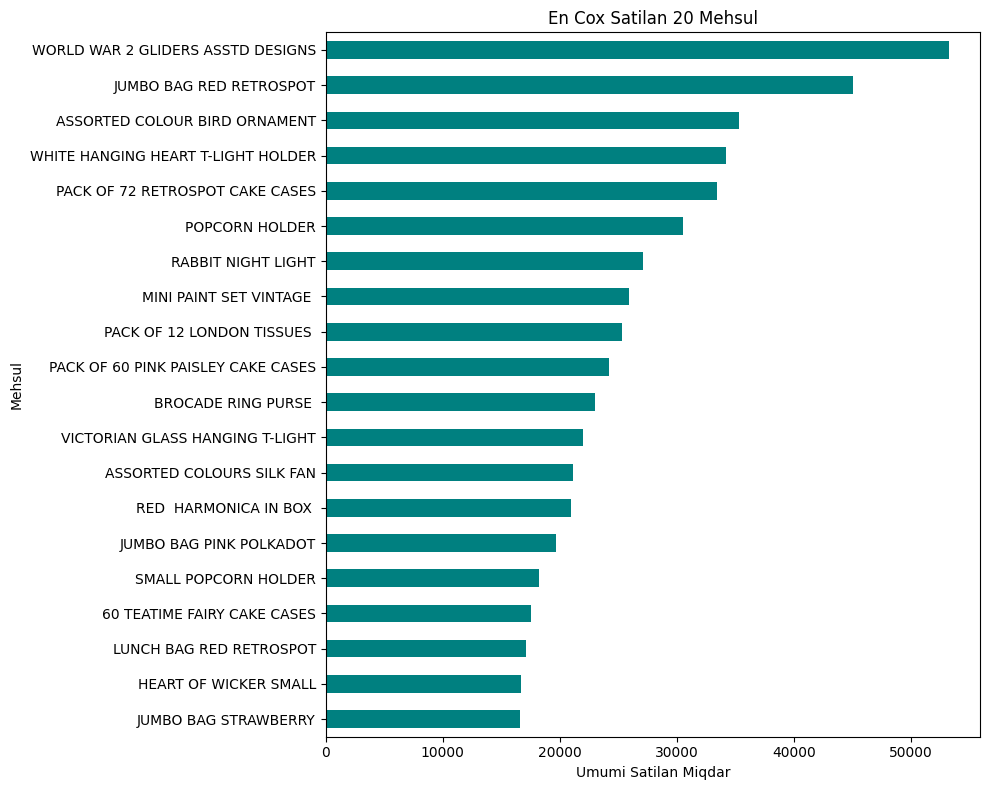

In [ ]:
en_cox_satilan = df_musteri.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

print("En Cox Satilan 20 Mehsul (Umumi Miqdara Gore):")
print(en_cox_satilan)

plt.figure(figsize=(10, 8))
en_cox_satilan.sort_values().plot(kind='barh', color='teal')
plt.title('En Cox Satilan 20 Mehsul')
plt.xlabel('Umumi Satilan Miqdar')
plt.ylabel('Mehsul')
plt.tight_layout()
plt.show()

In [ ]:
olke_legv_sayi = legv_edilmis.groupby('Country')['InvoiceNo'].nunique()

olke_umumi_sifaris = df.groupby('Country')['InvoiceNo'].nunique()

qaytarma_nisbeti = (olke_legv_sayi / olke_umumi_sifaris * 100).round(2)

qaytarma_nisbeti = qaytarma_nisbeti.dropna().sort_values(ascending=False)

print("Olke uzre Qaytarma Nisbeti (%):")
print(qaytarma_nisbeti.head(15))

Olke uzre Qaytarma Nisbeti (%):
Country
Czech Republic        60.00
Malta                 50.00
Saudi Arabia          50.00
Japan                 32.14
Italy                 30.91
Singapore             30.00
USA                   28.57
Switzerland           27.03
Hong Kong             26.67
Bahrain               25.00
Germany               24.21
Sweden                21.74
Channel Islands       21.21
Poland                20.83
European Community    20.00
Name: InvoiceNo, dtype: float64


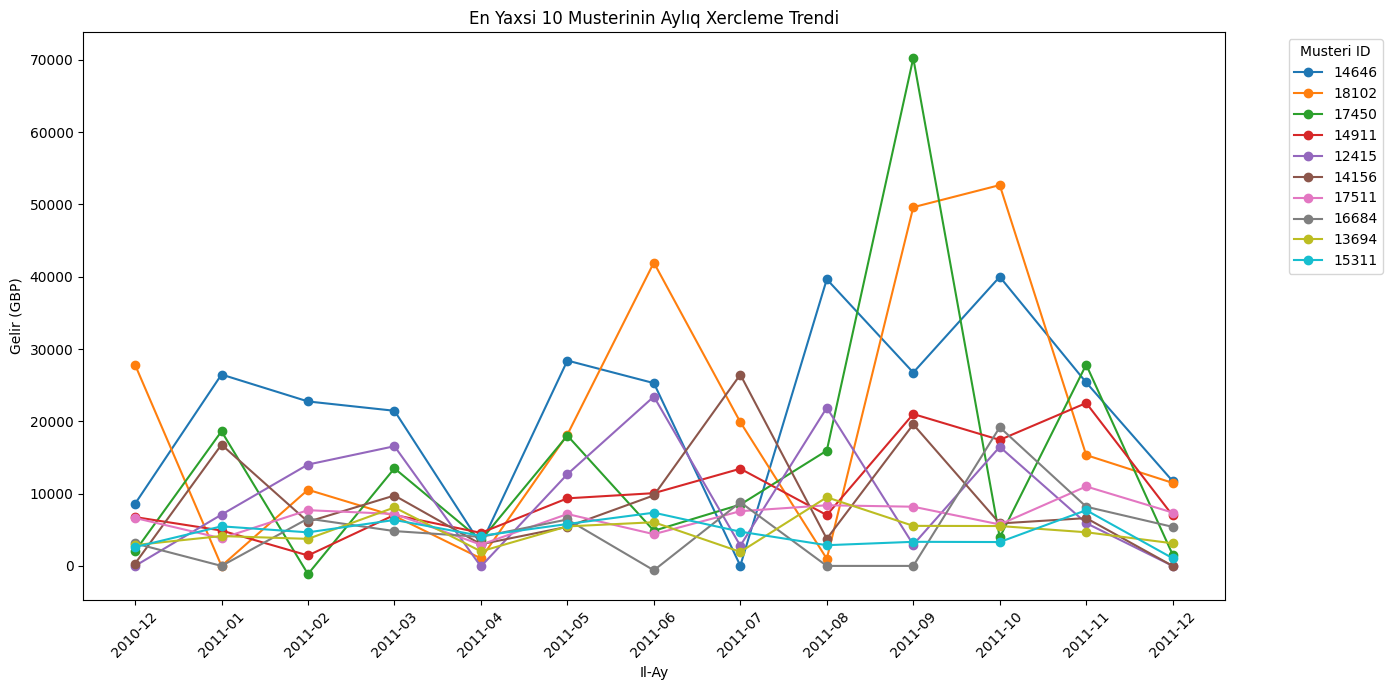

In [ ]:
en_yaxsi_10_id = musteri_xulasesi.head(10)['CustomerID'].tolist()

en_yaxsi_10_data = df_musteri[df_musteri['CustomerID'].isin(en_yaxsi_10_id)]

musteri_aylıq = en_yaxsi_10_data.groupby(['CustomerID', 'il_ay'])['Gelir'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
for musteri_id in en_yaxsi_10_id:
    plt.plot(musteri_aylıq.columns.astype(str), musteri_aylıq.loc[musteri_id], marker='o', label=str(musteri_id))

plt.title('En Yaxsi 10 Musterinin Aylıq Xercleme Trendi')
plt.xlabel('Il-Ay')
plt.ylabel('Gelir (GBP)')
plt.xticks(rotation=45)
plt.legend(title='Musteri ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Olke uzre Orta Sebet Olcusu (faktura basina unikal mehsul sayi):
Country
RSA            58.00
Lebanon        45.00
USA            41.57
Israel         41.17
Brazil         32.00
Cyprus         30.35
Unspecified    29.88
Norway         27.05
Switzerland    26.42
Iceland        26.00
Canada         25.17
Greece         24.33
Spain          23.92
Netherlands    23.48
EIRE           23.43
Name: StockCode, dtype: float64


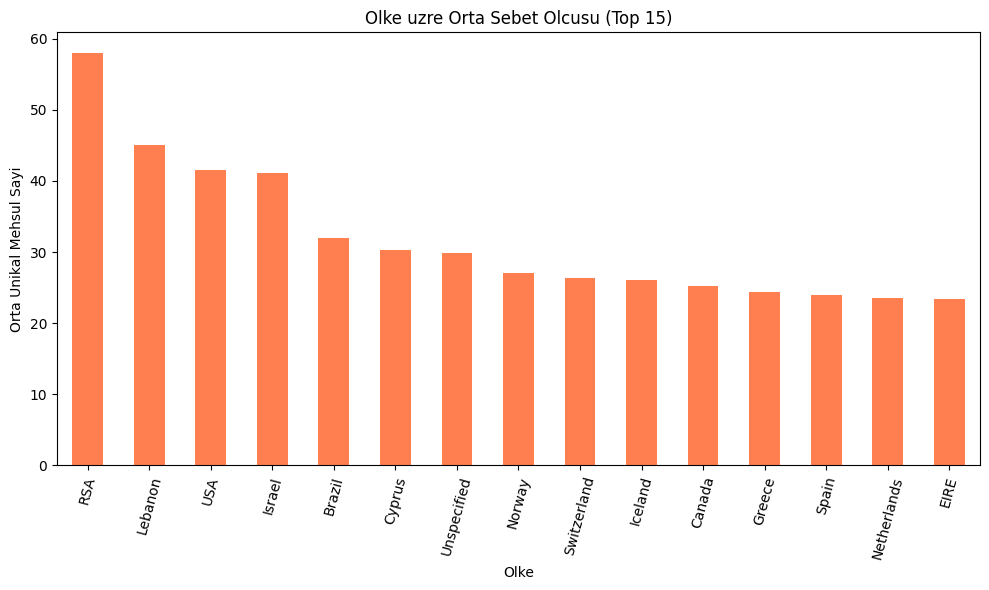

In [ ]:
sebet_olcusu = df_musteri.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique().reset_index()

olke_sebet_olcusu = sebet_olcusu.groupby('Country')['StockCode'].mean().round(2).sort_values(ascending=False)

print("Olke uzre Orta Sebet Olcusu (faktura basina unikal mehsul sayi):")
print(olke_sebet_olcusu.head(15))

plt.figure(figsize=(10, 6))
olke_sebet_olcusu.head(15).plot(kind='bar', color='coral')
plt.title('Olke uzre Orta Sebet Olcusu (Top 15)')
plt.xlabel('Olke')
plt.ylabel('Orta Unikal Mehsul Sayi')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

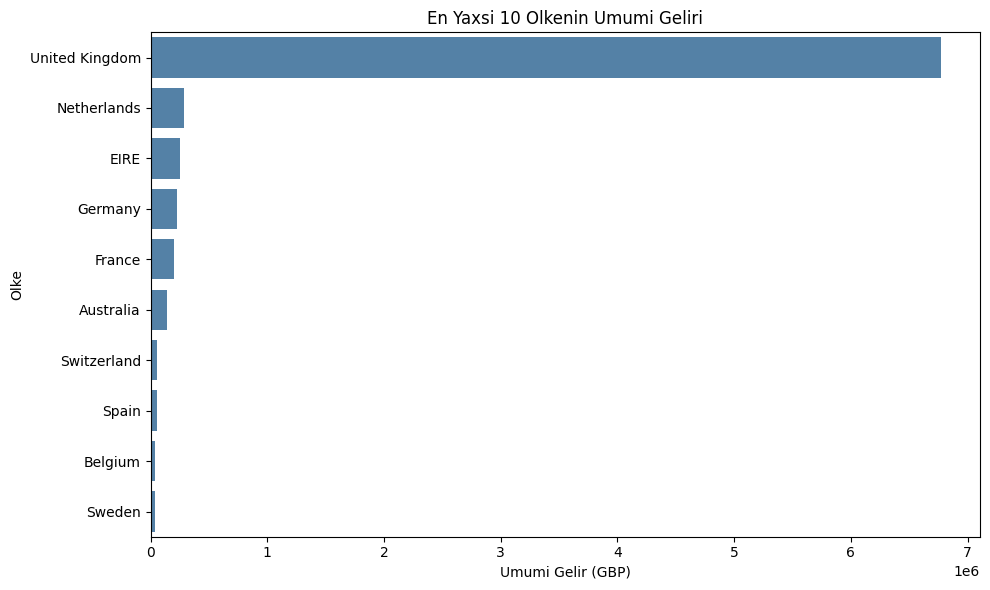

In [ ]:
en_yaxsi_10_olke = olke_xulasesi.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='umumi_gelir', y='Country', data=en_yaxsi_10_olke, color='steelblue')
plt.title('En Yaxsi 10 Olkenin Umumi Geliri')
plt.xlabel('Umumi Gelir (GBP)')
plt.ylabel('Olke')
plt.tight_layout()
plt.show()

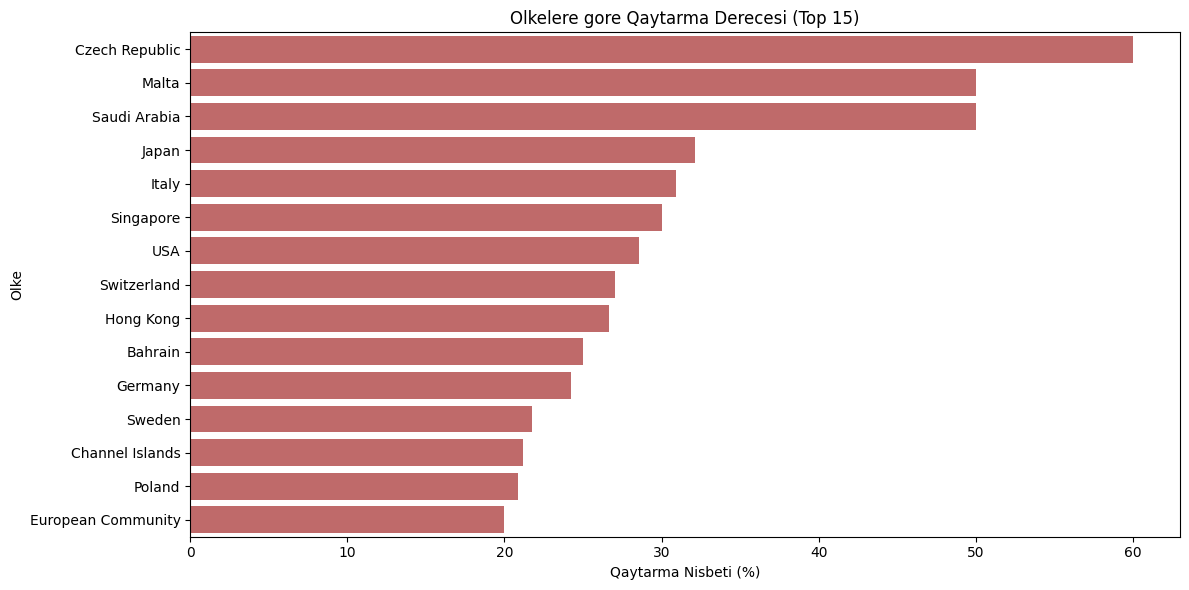

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=qaytarma_nisbeti.head(15).values, y=qaytarma_nisbeti.head(15).index, color='indianred')
plt.title('Olkelere gore Qaytarma Derecesi (Top 15)')
plt.xlabel('Qaytarma Nisbeti (%)')
plt.ylabel('Olke')
plt.tight_layout()
plt.show()

Biznes Anlayışları:

1. United Kingdom ümumi gəlirin 81.5%-ni təşkil edir, ardınca Netherlands (3.43%) və EIRE (3.02%) gəlir. Bu, biznesin tək bir bazara asılı olduğunu göstərir, risk azaltmaq üçün digər ölkələrə (xüsusilə Netherlands, Germany, France) daha çox diqqət verilə bilər.

2. Noyabr ayı ilin ən yüksək gəlirli ayıdır (1132407 GBP), aylıq gəlir Sentyabr-Noyabr arasında kəskin artır. Bu, stok və marketinq planlamasının bu aylara qədər tamamlanmasının vacib olduğunu göstərir.

3. Ən yaxşı müştəri (ID 14646) təkbaşına 279489 GBP gəlir gətirib, az sayda müştəri çox böyük gəlir təşkil edir. Bu müştərilərə xüsusi endirim və ya sadiqlik proqramı təklif etmək faydalı ola bilər.

4. Czech Republic (60%) və Malta (50%) ən yüksək qaytarma nisbətinə malikdir, amma bu ölkələrin sifariş sayı azdır. Real problem çox sifariş olan ölkələrdə (Germany 24%, USA 28.5%) daha ciddi araşdırılmalıdır.

5. RSA, Lebanon və USA kimi ölkələrdə müştərilər bir sifarişdə 40-58 unikal məhsul alır, halbuki əksər ölkələrdə bu rəqəm 15-25 arasındadır. Bu, topdan satış və ya hədiyyə alışı ola bilər, bu müştərilərə xüsusi şərtlər təklif olunması faydalı ola bilər.